<a href="https://colab.research.google.com/github/SebastianGustavoRojasPeralta/SIS420RojasPeraltaSebastian/blob/main/Laboratorios/Laboratorio04/Multimodal/Laboratorio04ClasificacionDatasetMultimodal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Laboratorio 04: Clasificación One vs All para dataset multimodal**

Nombre: Sebastian Gustavo Rojas Peralta

Dataset: Epileptic Seizure Recognition

**Preprocesamiento con Pandas**

Cargamos el dataset de lecturas de electroencefalogramas. Eliminamos la primera columna porque es solo un identificador de texto que no aporta valor predictivo. Además, las etiquetas originales van del 1 al 5; por buenas prácticas de programación, las restamos por 1 para que vayan del 0 al 4, lo que facilita enormemente el manejo de índices en las matrices más adelante.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import optimize

url = '/content/drive/MyDrive/machine learning/datsets/Epileptic Seizure Recognition.csv'
df = pd.read_csv(url)

# Eliminamos la primera columna (el ID de la lectura)
df = df.drop(df.columns[0], axis=1)

# Las clases vienen como 1, 2, 3, 4, 5. Las pasamos a 0, 1, 2, 3, 4.
df['y'] = df['y'] - 1

print("Formato del dataset:", df.shape)
print("Verificación de clases:", df['y'].unique())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Formato del dataset: (11500, 179)
Verificación de clases: [3 0 4 1 2]


**Verificación de Balanceo y Visualización Multimodal**

Este dataset ya viene con exactamente 2,300 ejemplos para cada una de las 5 clases. Para entender la naturaleza multimodal (señales de series de tiempo), graficamos un ejemplo aleatorio de la onda cerebral para cada estado del paciente.

Distribución de ejemplos por clase:
y
3    2300
0    2300
4    2300
1    2300
2    2300
Name: count, dtype: int64


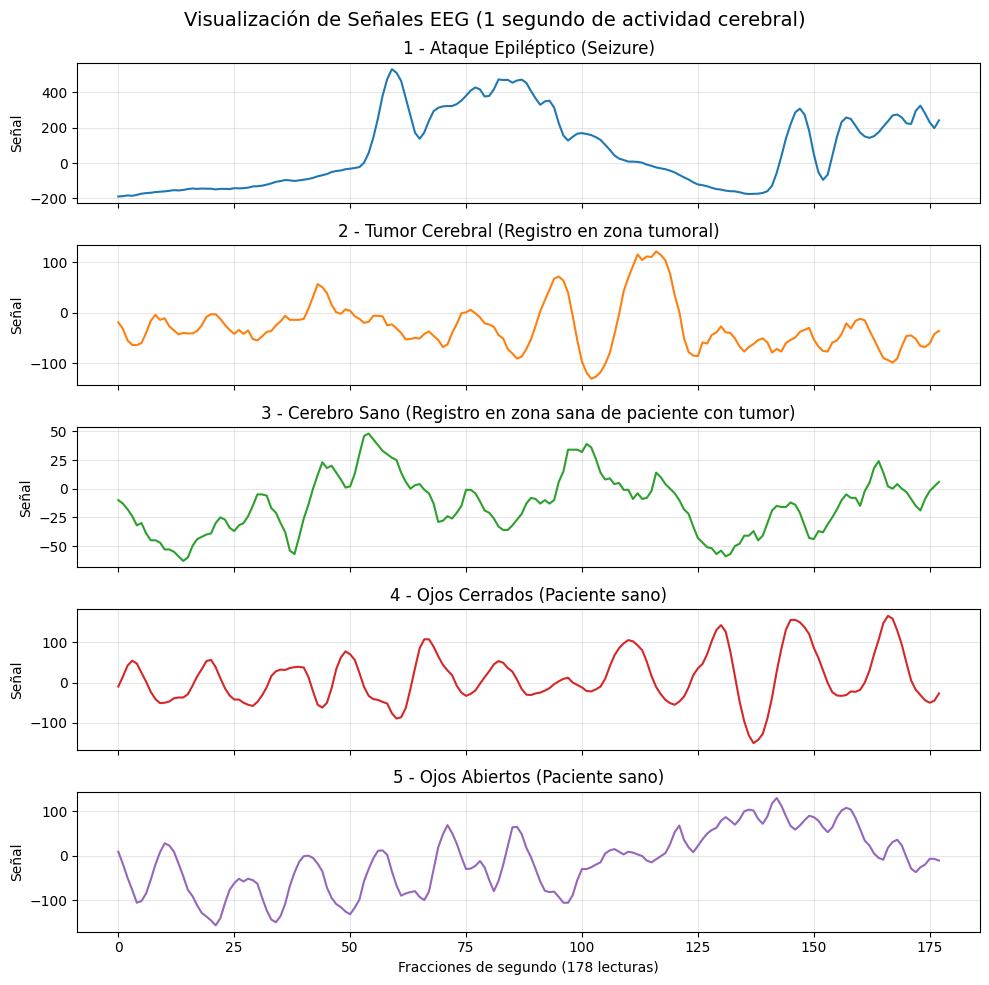

In [2]:
print("Distribución de ejemplos por clase:")
print(df['y'].value_counts())

# Nombres de las clases según la documentación médica del dataset
nombres_clases = [
    "1 - Ataque Epiléptico (Seizure)",
    "2 - Tumor Cerebral (Registro en zona tumoral)",
    "3 - Cerebro Sano (Registro en zona sana de paciente con tumor)",
    "4 - Ojos Cerrados (Paciente sano)",
    "5 - Ojos Abiertos (Paciente sano)"
]

# Vamos a graficar una onda de cada clase para ver cómo se comportan
fig, axes = plt.subplots(5, 1, figsize=(10, 10), sharex=True)
fig.suptitle('Visualización de Señales EEG (1 segundo de actividad cerebral)', fontsize=14)

for i in range(5):
    # Agarramos una fila al azar que pertenezca a la clase 'i'
    ejemplo = df[df['y'] == i].drop('y', axis=1).sample(1).values[0]

    axes[i].plot(ejemplo, color=plt.cm.tab10(i))
    axes[i].set_title(nombres_clases[i])
    axes[i].set_ylabel('Señal')
    axes[i].grid(True, alpha=0.3)

plt.xlabel('Fracciones de segundo (178 lecturas)')
plt.tight_layout()
plt.show()

**División 80/20 y Normalización**

Separamos nuestras lecturas ($X$) de los diagnósticos ($y$). Luego cortamos el dataset para usar el 80% en el entrenamiento y reservar el 20% para validar la efectividad real del modelo. Como las señales eléctricas varían en amplitud, normalizamos usando la media y desviación estándar del set de entrenamiento para lograr que el Descenso de Gradiente funcione rápido.

In [3]:
X = df.drop('y', axis=1).values
y = df['y'].values

# Cortamos en 80%
limite = int(len(y) * 0.8)

X_train, X_test = X[:limite], X[limite:]
y_train, y_test = y[:limite], y[limite:]

def normalizar(X):
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)
    sigma[sigma == 0] = 1
    return (X - mu) / sigma, mu, sigma

# Normalizamos todo basándonos SOLO en el entrenamiento
X_train_norm, mu, sigma = normalizar(X_train)
X_test_norm = (X_test - mu) / sigma

# Agregamos la columna de Unos para el Sesgo (Theta 0)
X_train_norm = np.concatenate([np.ones((X_train_norm.shape[0], 1)), X_train_norm], axis=1)
X_test_norm = np.concatenate([np.ones((X_test_norm.shape[0], 1)), X_test_norm], axis=1)

print("Datos listos para entrenar:", X_train_norm.shape)

Datos listos para entrenar: (9200, 179)


**Funciones (Sigmoide, Costo y Gradiente)**

Aquí definimos el núcleo de la Regresión Logística de manera puramente vectorial. La función de costo incluye el parámetro lambda_ para aplicar Regularización L2 (penalizando thetas muy grandes para evitar sobreajuste). Anulamos temporalmente el primer valor del theta para no penalizar la constante de sesgo

In [4]:
def sigmoide(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -250, 250)))

def lrCostFunction(theta, X, y, lambda_):
    m = y.size
    h = sigmoide(X.dot(theta))

    epsilon = 1e-15
    J = (1 / m) * np.sum(-y * np.log(h + epsilon) - (1 - y) * np.log(1 - h + epsilon))

    temp = theta.copy()
    temp[0] = 0
    reg = (lambda_ / (2 * m)) * np.sum(np.square(temp))

    return J + reg

def lrGradient(theta, X, y, lambda_):
    m = y.size
    h = sigmoide(X.dot(theta))

    temp = theta.copy()
    temp[0] = 0

    grad = (1 / m) * (X.T.dot(h - y)) + (lambda_ / m) * temp
    return grad

**Entrenamiento Multiclase (One-vs-All)**

Entrenamos 5 clasificadores binarios independientes usando el optimizador de Gradiente Conjugado de SciPy. Mientras se entrena, guardamos el historial del costo para poder graficar cómo va aprendiendo el modelo en cada iteración.

In [5]:
def oneVsAll(X, y, num_labels, lambda_):
    m, n = X.shape
    all_theta = np.zeros((num_labels, n))
    historiales_costo = {}

    for c in range(num_labels):
        y_c = (y == c).astype(int)
        initial_theta = np.zeros(n)
        cost_history_class = []

        def cost_wrapper(t):
            costo = lrCostFunction(t, X, y_c, lambda_)
            cost_history_class.append(costo)
            return costo

        # Optimizador de SciPy (Rápido y eficiente)
        res = optimize.minimize(cost_wrapper,
                                initial_theta,
                                jac=lambda t: lrGradient(t, X, y_c, lambda_),
                                method='CG',
                                options={'maxiter': 100})

        all_theta[c, :] = res.x
        historiales_costo[c] = cost_history_class
        print(f"Clase {c} entrenada con éxito. (Costo final: {res.fun:.4f})")

    return all_theta, historiales_costo

# 5 clases, aplicamos un poco de regularización
num_labels = 5
lambda_ = 0.1
all_theta, historiales = oneVsAll(X_train_norm, y_train, num_labels, lambda_)

Clase 0 entrenada con éxito. (Costo final: 0.4659)
Clase 1 entrenada con éxito. (Costo final: 0.4995)
Clase 2 entrenada con éxito. (Costo final: 0.4966)
Clase 3 entrenada con éxito. (Costo final: 0.4954)
Clase 4 entrenada con éxito. (Costo final: 0.4871)


**Predicción y Análisis de Resultados**

Por último, usamos los Thetas entrenados para predecir los diagnósticos del 20% de datos de prueba que el modelo nunca había visto. Calculamos las probabilidades usando la sigmoide y elegimos la clase ganadora con argmax. Finalmente, generamos las gráficas exigidas.

Precisión Final del Modelo EEG: 26.57%


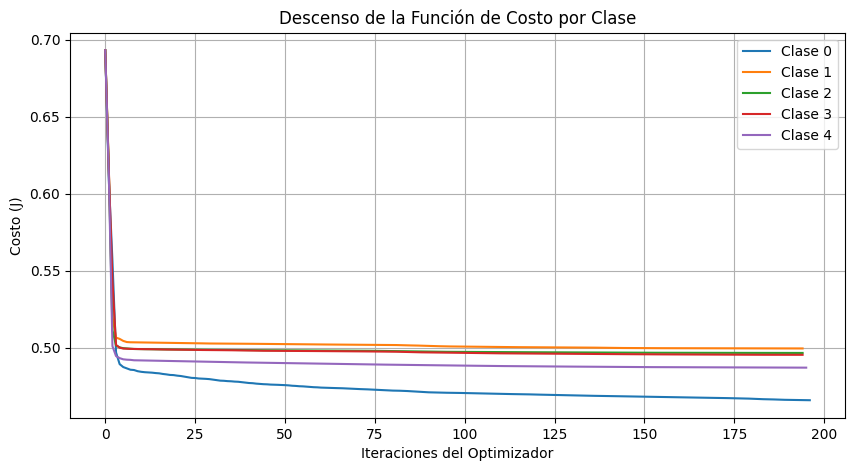

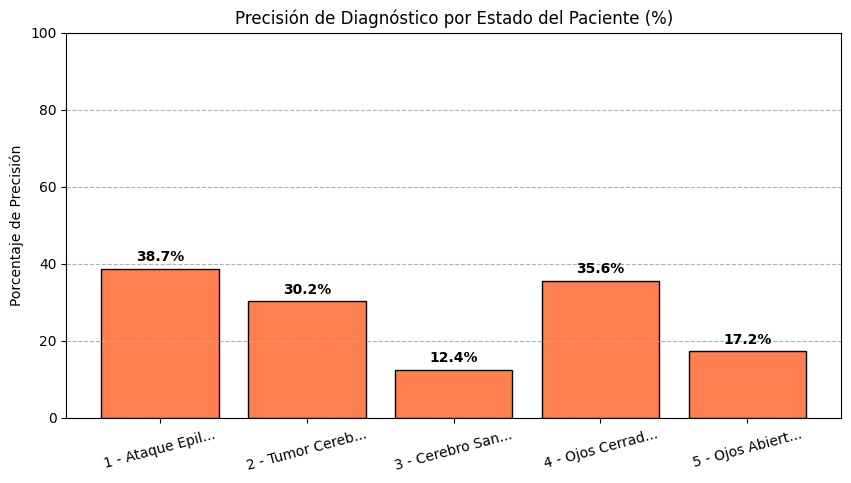

In [6]:
def predictOneVsAll(all_theta, X):
    probabilidades = sigmoide(X.dot(all_theta.T))
    return np.argmax(probabilidades, axis=1)

# Calculamos la precisión con los datos de Test
predicciones = predictOneVsAll(all_theta, X_test_norm)
precision = np.mean(predicciones == y_test) * 100

print(f"Precisión Final del Modelo EEG: {precision:.2f}%")


# --- GRÁFICA DE COSTO ---
plt.figure(figsize=(10, 5))
for c in range(num_labels):
    plt.plot(historiales[c], label=f'Clase {c}')

plt.title('Descenso de la Función de Costo por Clase')
plt.xlabel('Iteraciones del Optimizador')
plt.ylabel('Costo (J)')
plt.legend()
plt.grid(True)
plt.show()

# --- GRÁFICA DE PRECISIÓN ---
aciertos_por_clase = []
for c in range(num_labels):
    total_clase = np.sum(y_test == c)
    aciertos = np.sum((predicciones == c) & (y_test == c))
    porcentaje = (aciertos / total_clase) * 100 if total_clase > 0 else 0
    aciertos_por_clase.append(porcentaje)

plt.figure(figsize=(10, 5))
plt.bar([n[:15]+"..." for n in nombres_clases], aciertos_por_clase, color='coral', edgecolor='black')
plt.title('Precisión de Diagnóstico por Estado del Paciente (%)')
plt.ylabel('Porcentaje de Precisión')
plt.ylim(0, 100)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--')
for i, v in enumerate(aciertos_por_clase):
    plt.text(i, v + 2, f"{v:.1f}%", ha='center', fontweight='bold')
plt.show()